# Stage 27b — Two-Stage Warm-Start M2 (End-to-End)

**Pipeline:**
1. **Stage 1** — Train M4-attn(noent) until attention confirms L1/L2 uninformative
   (w_L1+L2 < 0.05 for 2 consecutive val checks, typically ep 35–40). Save intermediate checkpoint.
2. **Stage 2** — Transfer *encoder only* from Stage 1 checkpoint into a fresh M2(L3+L4).
   Decoder + prototypes randomly initialised. Train 100 epochs (3-phase) with only L3/L4 skips.

**Why ep 35–40 (not ep 100)?**
At ep 35, attention has collapsed L1/L2 but the encoder has not been contaminated by
60 more epochs of 4-level prototype supervision. We extract the encoder at the moment
it has learned good multi-scale features *and* before it degrades.

**Hypothesis (RQ9):** Warm-starting M2 with a discovery-epoch encoder improves over
cold-start M2 (0.8722) by providing better-initialised representations for L3/L4.

## 0. Config

In [1]:
import sys, os

_root = (
    os.path.dirname(os.getcwd())
    if os.path.basename(os.getcwd()) == "notebooks"
    else os.getcwd()
)
os.chdir(_root)
sys.path.insert(0, _root)
os.environ.setdefault("PYTORCH_MPS_HIGH_WATERMARK_RATIO", "0.0")
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42

# ── Pipeline control ──────────────────────────────────────────────────────────
SKIP_STAGE1 = True   # True = use existing STAGE1_CKPT, skip Stage 1 training

# ── Stage 1 config ────────────────────────────────────────────────────────────
S1_PROTO_LEVELS     = [1, 2, 3, 4]
STAGE1_CKPT         = "checkpoints/proto_seg_ct_l1234_attn_noent_ep40.pth"
STAGE1_ATTN_LOG     = "results/v6/attn_evolution_l1234_noent_stage1.csv"
STAGE1_MAX_EPOCHS   = 45
HIERARCHY_THRESHOLD = 0.05
HIERARCHY_PATIENCE  = 2
ATTN_WARMUP_EPOCHS  = 10
S1_PHASE_A_END      = 20

# ── Stage 2: Warm-start model ─────────────────────────────────────────────────
# Stage 1 converged to L4=0.63, L2=0.30, L3=0.06 → test all 3 active levels
PROTO_LEVELS        = [2, 3, 4]
USE_LEVEL_ATTENTION = False
MODALITY            = "ct"
SUFFIX              = "_l234_warmstart"
FREEZE_ENCODER_PHASE_A = False

# ── Shared hyperparameters ────────────────────────────────────────────────────
LAMBDA_DIV   = 0.001
LAMBDA_PUSH  = 0.5
LAMBDA_PULL  = 0.25
BATCH_SIZE   = 16
LR           = 3e-4
WEIGHT_DECAY = 1e-5
PHASE_A_END  = 20
PHASE_B_END  = 80
PHASE_C_END  = 100
VAL_EVERY    = 5
PATIENCE     = 15
PROJ_INTERVAL = 10

DATA_DIR = "data/pack/processed_data"
CKPT_DIR = "checkpoints"
LOG_DIR  = "results/v6"

import pathlib
pathlib.Path(LOG_DIR).mkdir(parents=True, exist_ok=True)

CKPT_PATH    = f"{CKPT_DIR}/proto_seg_{MODALITY}{SUFFIX}.pth"
PROJ_PATH    = f"{CKPT_DIR}/projected_prototypes_{MODALITY}{SUFFIX}.pt"
LOG_PATH     = f"{LOG_DIR}/train_curve_proto_{MODALITY}{SUFFIX}.csv"
S1_PROJ_PATH = f"{CKPT_DIR}/projected_prototypes_{MODALITY}_l1234_stage1.pt"

print(f"SKIP_STAGE1   : {SKIP_STAGE1}")
print(f"Stage 1 ckpt  : {STAGE1_CKPT}  (L4=0.63, L2=0.30, L3=0.06)")
print(f"Stage 2 levels: {PROTO_LEVELS}")
print(f"Stage 2 ckpt  : {CKPT_PATH}")

SKIP_STAGE1   : True
Stage 1 ckpt  : checkpoints/proto_seg_ct_l1234_attn_noent_ep40.pth  (L4=0.63, L2=0.30, L3=0.06)
Stage 2 levels: [2, 3, 4]
Stage 2 ckpt  : checkpoints/proto_seg_ct_l234_warmstart.pth


## 1. Imports & Device

In [2]:
import csv, time, random
import numpy as np
import matplotlib.pyplot as plt
import torch

from src.data.mmwhs_dataset import (
    MMWHSSliceDataset,
    make_dataloaders,
    LABEL_NAMES,
    NUM_CLASSES,
)
from src.models.proto_seg_net import ProtoSegNet
from src.models.prototype_layer import PrototypeProjection
from src.losses.segmentation import SegmentationLoss, compute_class_weights
from src.losses.diversity_loss import ProtoSegLoss
from src.metrics.dice import dice_per_class, mean_foreground_dice

# Fix seed for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"Seeds fixed: {SEED}")

DEVICE = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()
    else torch.device("cpu")
)
print(f"Device: {DEVICE}")

Seeds fixed: 42
Device: mps


## 2. Data & Class Weights

In [3]:
loaders = make_dataloaders(DATA_DIR, MODALITY, batch_size=BATCH_SIZE)
print(f"Train: {len(loaders['train'].dataset)}  Val: {len(loaders['val'].dataset)}  "
      f"Test: {len(loaders['test'].dataset)}")

class_weights = torch.load(f"data/class_weights_{MODALITY}.pt", weights_only=True)
print(f"Class weights: {class_weights.numpy().round(3)}")

Train: 3389  Val: 382  Test: 484
Class weights: [0.021 0.819 1.197 1.066 1.192 0.795 1.486 1.423]


## 3. Stage 1 — Train M4-attn(noent) to Discover Hierarchy

Train M4-attn(noent) from scratch. Stop when attention confirms L1/L2 are uninformative
(w_L1+L2 < 0.05 for 2 consecutive val epochs). Based on v5 reference run, this occurs
around ep 35–40 (5 epochs after attention warmup ends at ep 31).

In [4]:
# ── Stage 1 model ─────────────────────────────────────────────────────────────
s1_model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=S1_PROTO_LEVELS,
    use_level_attention=True,
).to(DEVICE)
print(f"Stage 1: proto_levels={S1_PROTO_LEVELS}  use_level_attention=True")
print(f"Total params: {s1_model.count_parameters()['total']:,}")

s1_seg_loss = SegmentationLoss(class_weights=class_weights.to(DEVICE), n_classes=NUM_CLASSES)
s1_criterion = ProtoSegLoss(
    seg_loss=s1_seg_loss,
    lambda_div=LAMBDA_DIV,
    lambda_push=LAMBDA_PUSH,
    lambda_pull=LAMBDA_PULL,
)

# ── Stage 1 helpers ───────────────────────────────────────────────────────────
@torch.no_grad()
def s1_validate(model, loader):
    model.eval()
    logits_list, labels_list = [], []
    for batch in loader:
        logits, _ = model(batch["image"].to(DEVICE))
        logits_list.append(logits.cpu())
        labels_list.append(batch["label"])
    model.train()
    return dice_per_class(torch.cat(logits_list), torch.cat(labels_list))


@torch.no_grad()
def s1_mean_attn(model, loader):
    model.eval()
    all_w = []
    for batch in loader:
        w = model.get_attention_weights(batch["image"].to(DEVICE))
        all_w.append(w.cpu())
    model.train()
    return torch.cat(all_w).mean(dim=0).numpy()


def s1_run_projection(model, save_path):
    print("  [S1 Proj] Building feature bank…", flush=True)
    t0 = time.time()
    proj_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, "train", augment=False, preload=True)
    proj_loader = torch.utils.data.DataLoader(proj_ds, batch_size=32, shuffle=False)
    wrapped = [(b["image"], b["label"]) for b in proj_loader]
    projector = PrototypeProjection(
        encoder=model.encoder,
        proto_layers=model.proto_layers_dict(),
        device="cpu",
    )
    projector.project(wrapped, save_path=save_path)
    model.to(DEVICE)
    ckpt = torch.load(save_path, weights_only=True)
    for level, proto_data in ckpt["proto_state"].items():
        model.proto_layers[str(level)].prototypes.data.copy_(proto_data)
    print(f"  [S1 Proj] Done in {time.time()-t0:.1f}s", flush=True)


def s1_set_phase(model, epoch, optimizer):
    if epoch <= S1_PHASE_A_END:
        model.unfreeze_all()
        model.freeze_prototypes()   # also freezes level_attention
        phase = "A"
    else:
        model.unfreeze_all()
        if epoch <= S1_PHASE_A_END + ATTN_WARMUP_EPOCHS:
            if model.level_attention is not None:
                for p in model.level_attention.parameters():
                    p.requires_grad_(False)
        phase = "B"
    optimizer.param_groups[0]["params"] = [p for p in model.parameters() if p.requires_grad]
    return phase


def s1_save_checkpoint(epoch, model, best_val_dice, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "best_val_dice": best_val_dice,
        "proto_levels": model.proto_levels,
        "use_level_attention": model.use_level_attention,
        "class_weights": class_weights,
        "lambda_div": LAMBDA_DIV,
        "lambda_push": LAMBDA_PUSH,
        "lambda_pull": LAMBDA_PULL,
        "single_scale": model.single_scale,
        "no_soft_mask": model.no_soft_mask,
        "hard_mask": model.hard_mask,
        "mask_quantile": model.mask_quantile,
        "hard_mask_active": model.hard_mask_active,
    }, path)

Stage 1: proto_levels=[1, 2, 3, 4]  use_level_attention=True
Total params: 2,587,308


In [5]:
if not SKIP_STAGE1:
    s1_model.freeze_prototypes()
    s1_optimizer = torch.optim.AdamW(
        [p for p in s1_model.parameters() if p.requires_grad],
        lr=LR, weight_decay=WEIGHT_DECAY,
    )
    s1_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(s1_optimizer, T_max=100)

    s1_attn_file = open(STAGE1_ATTN_LOG, "w", newline="")
    s1_attn_writer = csv.DictWriter(
        s1_attn_file,
        fieldnames=["epoch", "phase"] + [f"w_L{l}" for l in S1_PROTO_LEVELS],
    )
    s1_attn_writer.writeheader()

    s1_best_val, s1_best_epoch = 0.0, 0
    s1_current_phase = "A"
    hierarchy_ok_count = 0
    hierarchy_epoch = None

    print(f"Stage 1 training  max_epochs={STAGE1_MAX_EPOCHS}")
    print(f"Stop criterion: w_L1+L2 < {HIERARCHY_THRESHOLD} for {HIERARCHY_PATIENCE} consecutive val checks\n")

    for epoch in range(1, STAGE1_MAX_EPOCHS + 1):
        new_phase = s1_set_phase(s1_model, epoch, s1_optimizer)
        if new_phase != s1_current_phase:
            s1_current_phase = new_phase
            print(f"\n→ Phase B: attention + all params (warmup until ep {S1_PHASE_A_END + ATTN_WARMUP_EPOCHS})")
            s1_best_val, s1_best_epoch = 0.0, 0

        if (s1_current_phase == "B"
                and epoch > S1_PHASE_A_END + 1
                and (epoch - S1_PHASE_A_END) % PROJ_INTERVAL == 0):
            s1_run_projection(s1_model, S1_PROJ_PATH)

        t0 = time.time()
        s1_model.train()
        totals = dict(loss=0, dice_loss=0, ce_loss=0, div_loss=0, push_loss=0, pull_loss=0)
        n_batches = 0
        for batch in loaders["train"]:
            imgs = batch["image"].to(DEVICE)
            lbls = batch["label"].to(DEVICE)
            s1_optimizer.zero_grad()
            logits, hm = s1_model(imgs)
            if s1_current_phase == "A":
                out = s1_seg_loss(logits, lbls)
                out["div_loss"] = out["push_loss"] = out["pull_loss"] = torch.zeros(1, device=DEVICE)
            else:
                out = s1_criterion(logits, lbls, hm)
            out["loss"].backward()
            s1_optimizer.step()
            for k in totals:
                v = out.get(k, torch.tensor(0.0))
                totals[k] += v.item() if hasattr(v, "item") else float(v)
            n_batches += 1
        s1_scheduler.step()
        epoch_time = time.time() - t0
        avgs = {k: v / n_batches for k, v in totals.items()}

        if epoch % VAL_EVERY == 0 or epoch == STAGE1_MAX_EPOCHS:
            val_dice = s1_validate(s1_model, loaders["val"])
            val_mean = mean_foreground_dice(val_dice)
            attn_w = s1_mean_attn(s1_model, loaders["val"])

            row = {"epoch": epoch, "phase": s1_current_phase}
            for i, l in enumerate(S1_PROTO_LEVELS):
                row[f"w_L{l}"] = round(float(attn_w[i]), 4)
            s1_attn_writer.writerow(row)
            s1_attn_file.flush()

            attn_active = (s1_current_phase == "B"
                           and epoch > S1_PHASE_A_END + ATTN_WARMUP_EPOCHS)
            w_low = float(attn_w[0] + attn_w[1])
            if attn_active and w_low < HIERARCHY_THRESHOLD:
                hierarchy_ok_count += 1
            else:
                hierarchy_ok_count = 0

            if val_mean > s1_best_val:
                s1_best_val = val_mean
                s1_best_epoch = epoch
                s1_save_checkpoint(epoch, s1_model, s1_best_val, STAGE1_CKPT)

            mark = " ← best" if val_mean >= s1_best_val - 1e-6 else ""
            hier = f"  [hier {hierarchy_ok_count}/{HIERARCHY_PATIENCE}]" if attn_active else ""
            print(
                f"  [{s1_current_phase}] Ep {epoch:3d}/{STAGE1_MAX_EPOCHS} | "
                f"loss={avgs['loss']:.4f} | val={val_mean:.4f}{mark} | "
                f"w=[{','.join(f'{v:.2f}' for v in attn_w)}] w_L1+L2={w_low:.3f}{hier} | "
                f"{epoch_time:.1f}s",
                flush=True,
            )

            if hierarchy_ok_count >= HIERARCHY_PATIENCE:
                print(f"\n✅ Hierarchy confirmed at epoch {epoch}  (w_L1+L2={w_low:.4f})")
                s1_save_checkpoint(epoch, s1_model, s1_best_val, STAGE1_CKPT)
                hierarchy_epoch = epoch
                break

    s1_attn_file.close()
    if hierarchy_epoch is None:
        print(f"\n⚠️  Max epochs reached without confirmation.")
        hierarchy_epoch = s1_best_epoch
        s1_save_checkpoint(s1_best_epoch, s1_model, s1_best_val, STAGE1_CKPT)

    print(f"\nStage 1 complete — hierarchy at ep {hierarchy_epoch}, best val {s1_best_val:.4f}")
    print(f"Checkpoint: {STAGE1_CKPT}")

else:
    ckpt_info = torch.load(STAGE1_CKPT, map_location="cpu", weights_only=False)
    hierarchy_epoch = ckpt_info["epoch"]
    print(f"SKIP_STAGE1=True — using existing checkpoint: {STAGE1_CKPT}")
    print(f"  epoch={hierarchy_epoch}, best_val={ckpt_info['best_val_dice']:.4f}")

SKIP_STAGE1=True — using existing checkpoint: checkpoints/proto_seg_ct_l1234_attn_noent_ep40.pth
  epoch=45, best_val=0.7952


## 4. Verify Hierarchy & Init Warm-Start M2

Load the Stage 1 checkpoint, confirm attention hierarchy, then copy encoder weights
into a fresh M2(L3+L4) model. Decoder and prototype layers are randomly initialised.

In [6]:
import pandas as pd

src_ckpt = torch.load(STAGE1_CKPT, map_location="cpu", weights_only=False)
print(f"Stage 1 checkpoint : epoch {src_ckpt['epoch']}, best_val {src_ckpt['best_val_dice']:.4f}")
print(f"  proto_levels     : {src_ckpt.get('proto_levels')}")
print(f"  use_level_attn   : {src_ckpt.get('use_level_attention')}")

# Verify attention hierarchy from log
attn_log = pd.read_csv(STAGE1_ATTN_LOG)
r_final = attn_log.iloc[-1]
print(f"\nFinal attention weights (ep {int(r_final['epoch'])}):")
for l in S1_PROTO_LEVELS:
    print(f"  w_L{l} = {r_final[f'w_L{l}']:.4f}")

w_low_final = r_final["w_L1"] + r_final["w_L2"]
w_l4_final  = r_final["w_L4"]
print(f"\nw_L1+L2 = {w_low_final:.4f}  (strict target < {HIERARCHY_THRESHOLD})")
print(f"w_L4    = {w_l4_final:.4f}  (dominant-level check > 0.50)")

if w_low_final < HIERARCHY_THRESHOLD:
    print("✅ Strict hierarchy confirmed (w_L1+L2 < 0.05)")
elif w_l4_final > 0.50:
    print(f"⚠️  L2 feedback loop active (w_L2={r_final['w_L2']:.3f}) but L4 dominant ({w_l4_final:.3f})")
    print("   Proceeding — L4-focused encoder is still a valid warm-start for M2(L3+L4)")
else:
    raise RuntimeError(f"Hierarchy not confirmed: w_L4={w_l4_final:.3f} < 0.50 and w_L1+L2={w_low_final:.3f} > threshold")

# Init fresh M2(L3+L4)
model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=PROTO_LEVELS,
    use_level_attention=USE_LEVEL_ATTENTION,
).to(DEVICE)

# Transfer encoder weights
src_state = src_ckpt["model_state_dict"]
own_state = model.state_dict()
transferred, skipped = [], []
for k, v in src_state.items():
    if k.startswith("encoder.") and k in own_state and own_state[k].shape == v.shape:
        own_state[k].copy_(v)
        transferred.append(k)
    else:
        skipped.append(k)
model.load_state_dict(own_state)

print(f"\nTransferred : {len(transferred)} encoder tensors")
print(f"Skipped     : {len(skipped)} (proto_layers, decoder — random init)")
print(f"Model       : proto_levels={model.proto_levels}  attn={model.level_attention}")
print(f"Total params: {model.count_parameters()['total']:,}")

# Sanity: encoder differs from random init
fresh = ProtoSegNet(n_classes=NUM_CLASSES, proto_levels=PROTO_LEVELS).to("cpu")
src_p  = next(p for name, p in model.named_parameters() if "encoder" in name)
fresh_p = next(p for name, p in fresh.named_parameters() if "encoder" in name)
diff = (src_p.cpu() - fresh_p).abs().mean().item()
print(f"Encoder diff vs random init: {diff:.4f}  (should be > 0)")

Stage 1 checkpoint : epoch 45, best_val 0.7952
  proto_levels     : [1, 2, 3, 4]
  use_level_attn   : True

Final attention weights (ep 45):
  w_L1 = 0.0069
  w_L2 = 0.2979
  w_L3 = 0.0629
  w_L4 = 0.6323

w_L1+L2 = 0.3048  (strict target < 0.05)
w_L4    = 0.6323  (dominant-level check > 0.50)
⚠️  L2 feedback loop active (w_L2=0.298) but L4 dominant (0.632)
   Proceeding — L4-focused encoder is still a valid warm-start for M2(L3+L4)

Transferred : 72 encoder tensors
Skipped     : 34 (proto_layers, decoder — random init)
Model       : proto_levels=[2, 3, 4]  attn=None
Total params: 2,555,240
Encoder diff vs random init: 0.2283  (should be > 0)


## 5. Stage 2 — Loss & Helpers

In [7]:
seg_loss = SegmentationLoss(class_weights=class_weights.to(DEVICE), n_classes=NUM_CLASSES)
criterion = ProtoSegLoss(
    seg_loss=seg_loss,
    lambda_div=LAMBDA_DIV,
    lambda_push=LAMBDA_PUSH,
    lambda_pull=LAMBDA_PULL,
)

@torch.no_grad()
def validate(model, loader):
    model.eval()
    logits_list, labels_list = [], []
    for batch in loader:
        logits, _ = model(batch["image"].to(DEVICE))
        logits_list.append(logits.cpu())
        labels_list.append(batch["label"])
    model.train()
    return dice_per_class(torch.cat(logits_list), torch.cat(labels_list))


def run_projection(model, save_path):
    print("  [Projection] Building feature bank on CPU…", flush=True)
    t0 = time.time()
    proj_ds = MMWHSSliceDataset(DATA_DIR, MODALITY, "train", augment=False, preload=True)
    proj_loader = torch.utils.data.DataLoader(proj_ds, batch_size=32, shuffle=False)
    wrapped = [(b["image"], b["label"]) for b in proj_loader]
    projector = PrototypeProjection(
        encoder=model.encoder,
        proto_layers=model.proto_layers_dict(),
        device="cpu",
    )
    projector.project(wrapped, save_path=save_path)
    model.to(DEVICE)
    ckpt = torch.load(save_path, weights_only=True)
    for level, proto_data in ckpt["proto_state"].items():
        model.proto_layers[str(level)].prototypes.data.copy_(proto_data)
    print(f"  [Projection] Done in {time.time() - t0:.1f}s", flush=True)


def set_phase(model, epoch, optimizer):
    if epoch <= PHASE_A_END:
        model.unfreeze_all()
        model.freeze_prototypes()
        if FREEZE_ENCODER_PHASE_A:
            for p in model.encoder.parameters():
                p.requires_grad_(False)
        phase = "A"
    elif epoch <= PHASE_B_END:
        model.unfreeze_all()
        phase = "B"
    else:
        model.freeze_encoder_and_prototypes()
        phase = "C"
    optimizer.param_groups[0]["params"] = [p for p in model.parameters() if p.requires_grad]
    return phase


def save_checkpoint(epoch, model, best_val_dice):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "best_val_dice": best_val_dice,
        "proto_levels": model.proto_levels,
        "use_level_attention": model.use_level_attention,
        "class_weights": class_weights,
        "lambda_div": LAMBDA_DIV,
        "lambda_push": LAMBDA_PUSH,
        "lambda_pull": LAMBDA_PULL,
        "source_checkpoint": STAGE1_CKPT,
        "hierarchy_epoch": hierarchy_epoch,
        "single_scale": model.single_scale,
        "no_soft_mask": model.no_soft_mask,
        "hard_mask": model.hard_mask,
        "mask_quantile": model.mask_quantile,
        "hard_mask_active": model.hard_mask_active,
    }, CKPT_PATH)

## 6. Stage 2 Training Loop

Standard 3-phase protocol (identical to cold-start M2).
Warm-started encoder, decoder trained from scratch with L3/L4 skips only.

In [8]:
model.freeze_prototypes()
if FREEZE_ENCODER_PHASE_A:
    for p in model.encoder.parameters():
        p.requires_grad_(False)

optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR, weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE_C_END)

fieldnames = (
    ["epoch", "phase", "train_loss", "train_dice_loss", "train_ce_loss",
     "train_div_loss", "train_push_loss", "train_pull_loss",
     "val_mean_fg_dice", "lr", "epoch_time_s"]
    + [f"val_dice_{LABEL_NAMES[c]}" for c in range(1, NUM_CLASSES)]
)
csv_file = open(LOG_PATH, "w", newline="")
writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
writer.writeheader()

best_val_dice, best_epoch, no_improve = 0.0, 0, 0
current_phase = "A"
history = []

print(f"Stage 2 — warm-start M2  proto_levels={PROTO_LEVELS}  encoder from S1 ep {hierarchy_epoch}")
print(f"λ_div={LAMBDA_DIV}  λ_push={LAMBDA_PUSH}  λ_pull={LAMBDA_PULL}  freeze_enc_phA={FREEZE_ENCODER_PHASE_A}")
print(f"Phase A: epochs 1–{PHASE_A_END}  (prototypes frozen, decoder trains with L3/L4 skips)\n")

for epoch in range(1, PHASE_C_END + 1):
    new_phase = set_phase(model, epoch, optimizer)
    if new_phase != current_phase:
        current_phase = new_phase
        if current_phase == "B":
            print(f"\n→ Phase B: all params  (epochs {PHASE_A_END+1}–{PHASE_B_END})")
            best_val_dice, best_epoch, no_improve = 0.0, 0, 0
        elif current_phase == "C":
            print(f"\n→ Phase C: decoder only  (epochs {PHASE_B_END+1}–{PHASE_C_END})")

    if (
        current_phase == "B"
        and epoch > PHASE_A_END + 1
        and (epoch - PHASE_A_END) % PROJ_INTERVAL == 0
    ):
        run_projection(model, PROJ_PATH)

    # Train epoch
    t0 = time.time()
    model.train()
    totals = dict(loss=0, dice_loss=0, ce_loss=0, div_loss=0, push_loss=0, pull_loss=0)
    n_batches = 0

    for batch in loaders["train"]:
        imgs = batch["image"].to(DEVICE)
        lbls = batch["label"].to(DEVICE)
        optimizer.zero_grad()
        logits, hm = model(imgs)

        if current_phase == "A":
            out = seg_loss(logits, lbls)
            out["div_loss"] = out["push_loss"] = out["pull_loss"] = torch.zeros(1, device=DEVICE)
        else:
            out = criterion(logits, lbls, hm)

        out["loss"].backward()
        optimizer.step()

        for k in totals:
            v = out.get(k, torch.tensor(0.0))
            totals[k] += v.item() if hasattr(v, "item") else float(v)
        n_batches += 1

    scheduler.step()
    epoch_time = time.time() - t0
    avgs = {k: v / n_batches for k, v in totals.items()}

    # Validation
    val_dice_dict = None
    val_mean = float("nan")
    if epoch % VAL_EVERY == 0 or epoch == PHASE_C_END:
        val_dice_dict = validate(model, loaders["val"])
        val_mean = mean_foreground_dice(val_dice_dict)

        improved = val_mean > best_val_dice
        if improved:
            best_val_dice = val_mean
            best_epoch = epoch
            no_improve = 0
            save_checkpoint(epoch, model, best_val_dice)
        else:
            no_improve += VAL_EVERY

        mark = " ← best" if improved else ""
        print(
            f"  [{current_phase}] Ep {epoch:3d}/{PHASE_C_END} | "
            f"loss={avgs['loss']:.4f} "
            f"(D={avgs['dice_loss']:.4f} CE={avgs['ce_loss']:.4f} "
            f"div={avgs['div_loss']:.4f} push={avgs['push_loss']:.4f} pull={avgs['pull_loss']:.4f}) | "
            f"val={val_mean:.4f}{mark} | "
            f"lr={scheduler.get_last_lr()[0]:.2e} | {epoch_time:.1f}s",
            flush=True,
        )

    row = {
        "epoch": epoch, "phase": current_phase,
        "train_loss": avgs["loss"], "train_dice_loss": avgs["dice_loss"],
        "train_ce_loss": avgs["ce_loss"], "train_div_loss": avgs["div_loss"],
        "train_push_loss": avgs["push_loss"], "train_pull_loss": avgs["pull_loss"],
        "val_mean_fg_dice": val_mean if val_dice_dict else None,
        "lr": scheduler.get_last_lr()[0], "epoch_time_s": epoch_time,
    }
    if val_dice_dict:
        for c in range(1, NUM_CLASSES):
            row[f"val_dice_{LABEL_NAMES[c]}"] = val_dice_dict.get(LABEL_NAMES[c], float("nan"))
    writer.writerow(row)
    csv_file.flush()
    history.append(row)

csv_file.close()
print(f"\nBest val Dice : {best_val_dice:.4f} at epoch {best_epoch}")
print(f"Checkpoint    : {CKPT_PATH}")

Stage 2 — warm-start M2  proto_levels=[2, 3, 4]  encoder from S1 ep 45
λ_div=0.001  λ_push=0.5  λ_pull=0.25  freeze_enc_phA=False
Phase A: epochs 1–20  (prototypes frozen, decoder trains with L3/L4 skips)



  [A] Ep   5/100 | loss=0.1171 (D=0.1377 CE=0.0965 div=0.0000 push=0.0000 pull=0.0000) | val=0.8059 ← best | lr=2.98e-04 | 28.9s


  [A] Ep  10/100 | loss=0.0831 (D=0.0923 CE=0.0739 div=0.0000 push=0.0000 pull=0.0000) | val=0.7999 | lr=2.93e-04 | 29.0s


  [A] Ep  15/100 | loss=0.0660 (D=0.0744 CE=0.0575 div=0.0000 push=0.0000 pull=0.0000) | val=0.8215 ← best | lr=2.84e-04 | 29.2s


  [A] Ep  20/100 | loss=0.0626 (D=0.0705 CE=0.0547 div=0.0000 push=0.0000 pull=0.0000) | val=0.7793 | lr=2.71e-04 | 29.3s


...

  [C] Ep  85/100 | loss=0.0095 (D=0.0578 CE=0.0426 div=212.0238 push=-0.8932 pull=0.7755) | val=0.8100 | lr=1.63e-05 | 23.2s


  [C] Ep  90/100 | loss=0.0100 (D=0.0586 CE=0.0423 div=212.1458 push=-0.8928 pull=0.7753) | val=0.8117 | lr=7.34e-06 | 23.2s


  [C] Ep  95/100 | loss=0.0084 (D=0.0569 CE=0.0415 div=211.8469 push=-0.8930 pull=0.7754) | val=0.8137 | lr=1.85e-06 | 23.1s


  [C] Ep 100/100 | loss=0.0081 (D=0.0565 CE=0.0414 div=211.8986 push=-0.8932 pull=0.7756) | val=0.8124 | lr=0.00e+00 | 23.0s



Best val Dice : 0.8191 at epoch 65
Checkpoint    : checkpoints/proto_seg_ct_l234_warmstart.pth


## 7. Training Curves

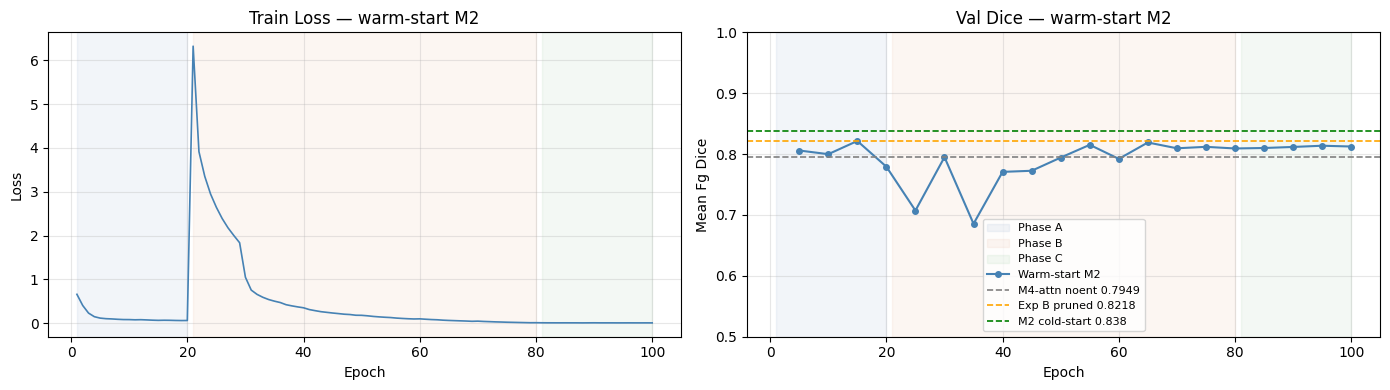

Best val Dice: 0.8215 at epoch 15


In [9]:
log = pd.read_csv(LOG_PATH)
val = log.dropna(subset=["val_mean_fg_dice"])

# Baselines
NOENT_VAL   = 0.7949   # M4-attn noent best val
M2_VAL      = 0.8380   # M2 cold-start best val
PRUNED_VAL  = 0.8218   # Exp B best val

PHASE_COLORS = {"A": "#4C72B0", "B": "#DD8452", "C": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax in axes:
    for ph, color in PHASE_COLORS.items():
        mask = log["phase"] == ph
        if mask.any():
            ax.axvspan(log.loc[mask, "epoch"].min(), log.loc[mask, "epoch"].max(),
                       alpha=0.07, color=color, label=f"Phase {ph}")

axes[0].plot(log["epoch"], log["train_loss"], lw=1.2, color="steelblue")
axes[0].set(title=f"Train Loss — warm-start M2", xlabel="Epoch", ylabel="Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(val["epoch"], val["val_mean_fg_dice"], "o-", ms=4, lw=1.5,
             color="steelblue", label="Warm-start M2")
axes[1].axhline(NOENT_VAL,  color="gray",   ls="--", lw=1.2, label=f"M4-attn noent {NOENT_VAL}")
axes[1].axhline(PRUNED_VAL, color="orange", ls="--", lw=1.2, label=f"Exp B pruned {PRUNED_VAL}")
axes[1].axhline(M2_VAL,     color="green",  ls="--", lw=1.2, label=f"M2 cold-start {M2_VAL}")
axes[1].set(title="Val Dice — warm-start M2", xlabel="Epoch", ylabel="Mean Fg Dice", ylim=(0.5, 1.0))
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{LOG_DIR}/train_curve{SUFFIX}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best val Dice: {val['val_mean_fg_dice'].max():.4f} at epoch {val.loc[val['val_mean_fg_dice'].idxmax(), 'epoch']}")

## 8. 3D Dice Evaluation

In [10]:
from src.data.mmwhs_dataset import MMWHSPatientDataset

ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
eval_model = ProtoSegNet(
    n_classes=NUM_CLASSES,
    proto_levels=ckpt["proto_levels"],
    use_level_attention=ckpt.get("use_level_attention", False),
).to(DEVICE)
eval_model.load_state_dict(ckpt["model_state_dict"])
eval_model.eval()
print(f"Loaded epoch {ckpt['epoch']}  best_val {ckpt['best_val_dice']:.4f}")


@torch.no_grad()
def eval_3d(model, modality):
    ds = MMWHSPatientDataset(DATA_DIR, modality, "test")
    results = {}
    for i in range(len(ds)):
        s = ds[i]
        imgs = s["image"].to(DEVICE)
        logits_all = [model(imgs[si:si+1])[0].cpu() for si in range(imgs.shape[0])]
        results[s["patient"]] = dice_per_class(torch.cat(logits_all), s["label"])
    return results


results = eval_3d(eval_model, MODALITY)
FG_NAMES = [LABEL_NAMES[c] for c in range(1, NUM_CLASSES)]

# Baselines for comparison
M4_3D      = 0.8407
NOENT_3D   = 0.8416
WLOSS_3D   = 0.8475
PRUNED_3D  = 0.8290
M2_3D      = 0.8722

print(f"\n3D Dice — warm-start M2 vs baselines")
print(f"{'Patient':<12} {'MeanFg':>7}  " + "  ".join(f"{n[:4]:>5}" for n in FG_NAMES))
print("─" * 75)
all_means = []
for pid, dice in sorted(results.items()):
    mfg = mean_foreground_dice(dice)
    all_means.append(mfg)
    vals = "  ".join(f"{dice.get(n, float('nan')):>5.3f}" for n in FG_NAMES)
    print(f"{pid:<12} {mfg:>7.4f}  {vals}")
overall = np.mean(all_means)
print("─" * 75)
print(f"{'Mean':<12} {overall:>7.4f}")
print()
print(f"Δ vs M4-attn-noent ({NOENT_3D:.4f}) : {overall - NOENT_3D:+.4f}")
print(f"Δ vs M4-attn-wloss ({WLOSS_3D:.4f}) : {overall - WLOSS_3D:+.4f}")
print(f"Δ vs Exp B pruned  ({PRUNED_3D:.4f}) : {overall - PRUNED_3D:+.4f}")
print(f"Δ vs M2 cold-start ({M2_3D:.4f})    : {overall - M2_3D:+.4f}")
print()
print(f"Target ≥ M2 (0.8722) : {'✅' if overall >= M2_3D else f'❌  ({overall:.4f})'} ")
print(f"Target ≥ 0.8600      : {'✅' if overall >= 0.86 else f'❌  ({overall:.4f})'} ")

Loaded epoch 65  best_val 0.8191



3D Dice — warm-start M2 vs baselines
Patient       MeanFg     LV     RV     LA     RA   Myoc   Aort     PA
───────────────────────────────────────────────────────────────────────────
ct_1019       0.7985  0.803  0.909  0.695  0.878  0.736  0.820  0.748
ct_1020       0.9284  0.887  0.955  0.936  0.910  0.918  0.974  0.919
───────────────────────────────────────────────────────────────────────────
Mean          0.8635

Δ vs M4-attn-noent (0.8416) : +0.0219
Δ vs M4-attn-wloss (0.8475) : +0.0160
Δ vs Exp B pruned  (0.8290) : +0.0345
Δ vs M2 cold-start (0.8722)    : -0.0087

Target ≥ M2 (0.8722) : ❌  (0.8635) 
Target ≥ 0.8600      : ✅ 


## 9. Summary Table

In [11]:
rows = [
    ("M4 (max)",              "max",          M4_3D),
    ("M4-attn noent (src)",   "learned",      NOENT_3D),
    ("M4-attn wloss (Exp A)", "learned+wloss", WLOSS_3D),
    ("M4-attn pruned (Exp B)","learned+prune", PRUNED_3D),
    ("Warm-start M2 (Exp C)", "warm+L3L4",    overall),
    ("M2 cold-start",         "max",          M2_3D),
]

print(f"{'Model':<28} {'Mechanism':<15} {'3D Dice':>8}  {'Δ vs M2':>8}")
print("─" * 65)
for name, mech, dice in rows:
    marker = " ←" if name.startswith("Warm") else ""
    print(f"{name:<28} {mech:<15} {dice:>8.4f}  {dice - M2_3D:>+8.4f}{marker}")

Model                        Mechanism        3D Dice   Δ vs M2
─────────────────────────────────────────────────────────────────
M4 (max)                     max               0.8407   -0.0315
M4-attn noent (src)          learned           0.8416   -0.0306
M4-attn wloss (Exp A)        learned+wloss     0.8475   -0.0247
M4-attn pruned (Exp B)       learned+prune     0.8290   -0.0432
Warm-start M2 (Exp C)        warm+L3L4         0.8635   -0.0087 ←
M2 cold-start                max               0.8722   +0.0000
